<a href="https://colab.research.google.com/github/Nyfeu/Data-Science/blob/main/IMT_ex_avaliativo_graphs_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<head>
  <meta name="author" content="Rogério de Oliveira">
  <meta institution="author" content="ITM">
</head>

<img src="https://maua.br/images/selo-60-anos-maua.svg" width=300, align="right">
<!-- <h1 align=left><font size = 6, style="color:rgb(200,0,0)"> optional title </font></h1> -->




In [102]:
#@markdown >
#@markdown **Atividade INDIVIDUAL ou EM DUPLA**
#@markdown
#@markdown > Nome **COMPLETO** e RA

Aluno1 = 'André Solano Ferreira Rodrigues Maiolini' #@param {type:"string"}
RA1 = '19.02012-0' #@param {type:"string"}
#@markdown
Aluno2 = 'Durval Consorti Soranz de Barros Santos' #@param {type:"string"}
RA2 = '22.01097-0' #@param {type:"string"}

suffix_file_1 = RA1.replace('.','')
suffix_file_2 = RA2.replace('.','')


In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "https://github.com/Rogerio-mack/IMT_CD_2026/raw/refs/heads/main/data/"


# **Case: Café**

Marcas de café têm na embalagem anotado que o peso líquido é de 1 Kg $\pm$ 0.05 (distribuição normal). Você quer fazer uma rotina para analisar amostras de diferentes fornecedores, rejeitando fornecedores cuja as amostras estão estão abaixo do intervalo de confiança de 95% do peso, embora aceite pesos acima. Para facilitar o uso da rotina pelo time comercial você faz uma rotina que exibe o resultado sobre as amostras como a seguir, seguindo as figuras (exceto a cor sobreada sobre o gráfico) o mais próximo possível (fontes, tamanho, ornamentos etc.).

**Assinatura da função a ser criada**: `def analisa_amostra(df, mu, sigma, ax)`

**Importante**: **Substitua o sombreado azul da imagem por uma COR DE SUA PREFERÊNCIA**







## Testes Café 1

In [104]:
df1 = pd.read_csv(path + 'amostra_cafe_1.csv')
display(df1.head())
df2 = pd.read_csv(path + 'amostra_cafe_2.csv')
display(df2.head())
df3 = pd.read_csv(path + 'amostra_cafe_3.csv')
display(df3.head())

,peso_cafe
0,1.006539
1,0.922261
2,0.883683
3,0.979279
4,1.007257


,peso_cafe
0,1.002032
1,0.941586
2,0.991946
3,1.001016
4,1.058258


,peso_cafe
0,0.964969
1,0.920406
2,0.984333
3,1.056115
4,0.918081


In [105]:
def analisa_amostra(df, mu, sigma, ax):

    from scipy.stats import norm

    # 1. Criação da Distribuição "Congelada"
    # Isso guarda o mu e sigma no objeto, deixando o código muito mais limpo.
    dist = norm(loc=mu, scale=sigma)

    # 2. Cálculo direto do intervalo de confiança (95%)
    # O método .interval já retorna os limites inferior e superior exatos!
    lim_inf, lim_sup = dist.interval(0.95)

    # 3. Eixos X e Y para a curva (4 desvios padrões para cada lado)
    eixo_x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    eixo_y = dist.pdf(eixo_x)

    # 4. Traça a curva principal (sem cor definida para usar o azul padrão do matplotlib)
    ax.plot(eixo_x, eixo_y)

    # 5. Preenchimento da área (Sombreado customizado: '#debff2')
    x_fill = np.linspace(lim_inf, lim_sup, 100)
    ax.fill_between(x_fill, dist.pdf(x_fill), color='#debff2', alpha=0.8)

    # 6. Linhas verticais dos limites
    y_limite = dist.pdf(lim_inf)
    ax.vlines(lim_inf, 0, y_limite, color='#921010', linewidth=2, label='inf')
    ax.vlines(lim_sup, 0, y_limite, color='#018001', linewidth=2, label='sup')

    # 7. Texto central "95%"
    ax.text(mu, dist.pdf(mu) / 2, '95%', ha='center', va='center',
            fontsize=16, fontweight='bold', color='#4646AA')

    # 8. Cálculo da amostra (Verificação vetorizada, muito mais rápida)
    # Pega a coluna 'peso_cafe' (ou a primeira coluna se o nome for diferente)
    coluna_peso = 'peso_cafe' if 'peso_cafe' in df.columns else df.columns[0]
    pct_abaixo = (df[coluna_peso] < lim_inf).mean() * 100

    # 9. Posições base para os textos e setas dinâmicas
    ymin, ymax = ax.get_ylim()
    posicao_texto = (mu - 3 * sigma, (ymax - ymin) / 4)

    # 10. Lógica de Aprovação/Rejeição
    if pct_abaixo > 2.5:
        texto = f"Fornecedor Rejeitado\nEncontrados {pct_abaixo:.2f}% abaixo do peso"
        ponto_seta = (dist.ppf(0.015), dist.pdf(dist.ppf(0.015)) / 2) # Aponta para a cauda
        cor_tema = '#921010'
    else:
        texto = f"Fornecedor Aceito\nEncontrados {100 - pct_abaixo:.2f}% acima do peso mínimo"
        ponto_seta = (mu, dist.pdf(mu) / 8) # Aponta para o centro
        cor_tema = '#036603'

    ax.annotate(texto,
                xy=ponto_seta,
                xytext=posicao_texto,
                arrowprops=dict(arrowstyle="->", color=cor_tema),
                fontweight='bold',
                color=cor_tema,
                fontsize=9)

    # 11. Ornamentos Finais (Títulos e Labels)
    ax.set_title('Análise da Amostra', fontsize=14, fontweight='bold', color='#4646AA')
    ax.set_xlabel('Peso Esperado (Distribuição Normal)', color='#4646AA')
    ax.set_ylabel('Densidade de Probabilidade', color='#4646AA')
    ax.legend(fontsize=10)

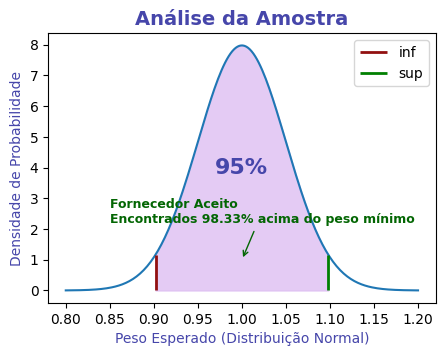

In [106]:
fig, ax = plt.subplots(1,1,figsize=(5, 3.5))

mu = 1
sigma = 0.05

analisa_amostra(df3, mu, sigma, ax)
plt.show()

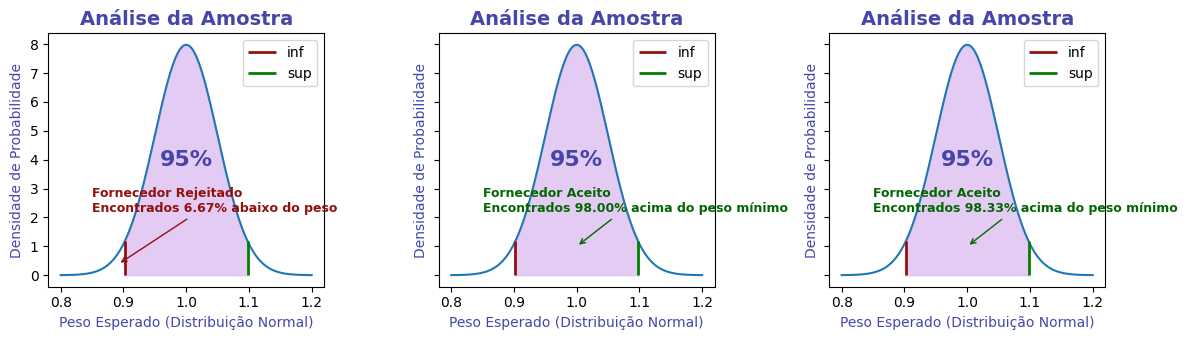

In [107]:
fig, ax = plt.subplots(1,3,figsize=(12, 3.5),sharey=True)

mu = 1
sigma = 0.05

for i, df in zip(range(3),[df1, df2, df3]):
  analisa_amostra(df, mu, sigma, ax[i])

plt.tight_layout()
plt.show()

### Salve sua imagem

Salve e poste a sua imagem (uma única imagem) com o seu RA (Files com RA de cada aluno!).

In [108]:
#@markdown Arquivos por aluno
from IPython.display import display, HTML
ativ = 'Coffe1_'
if RA2 != '':
  content = f'{Aluno1}, salvar e postar a imagem <b>{ativ}{suffix_file_1}_A.png</b>'
  content = f'<span style="font-size: 18px; color: blue;">{content}</span>'
  # display(HTML('<span style="font-family: Georgia; font-size: 24px; color: blue;">Respostas</span>'))
  display(HTML(content))
  print()
  content = f'{Aluno2}, salvar e postar a imagem <b>{ativ}{suffix_file_2}_B.png</b>'
  content = f'<span style="font-size: 18px; color: blue;">{content}</span>'
  display(HTML(content))
else:
  content = f'{Aluno1}, salvar e postar a imagem <b>{ativ}{suffix_file_1}.png</b>'
  content = f'<span style="font-size: 18px; color: blue;">{content}</span>'
  # display(HTML('<span style="font-family: Georgia; font-size: 24px; color: blue;">Respostas</span>'))
  display(HTML(content))
  print()

## Teste Café 2

A rotina ainda deve funcionar para outras embalagens de café, como sacas de 60Kg, pacotes de 10 e 5Kg etc. que apresentam peso médio e desvio padrão diferente. Abaixo, a análise de sacas de 60Kg $\pm$ 0.1.

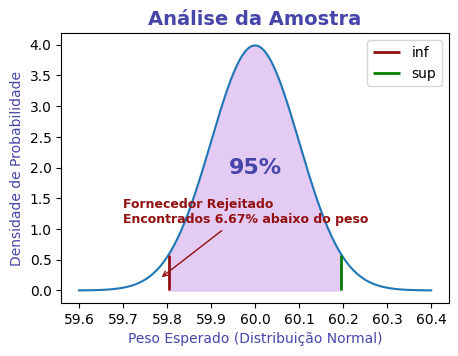

In [109]:
df_saca = pd.read_csv(path + 'amostra_cafe_extra.csv')

fig, ax = plt.subplots(1,1,figsize=(5, 3.5))

mu = 60
sigma = 0.1

analisa_amostra(df_saca, mu, sigma, ax)
plt.show()

### Salve sua imagem

Salve e poste a sua imagem com o seu RA (Files com RA de cada aluno!).

In [110]:
#@markdown Arquivos por aluno
from IPython.display import display, HTML
ativ = 'Coffe2_'
if RA2 != '':
  content = f'{Aluno1}, salvar e postar a imagem <b>{ativ}{suffix_file_1}_A.png</b>'
  content = f'<span style="font-size: 18px; color: blue;">{content}</span>'
  # display(HTML('<span style="font-family: Georgia; font-size: 24px; color: blue;">Respostas</span>'))
  display(HTML(content))
  print()
  content = f'{Aluno2}, salvar e postar a imagem <b>{ativ}{suffix_file_2}_B.png</b>'
  content = f'<span style="font-size: 18px; color: blue;">{content}</span>'
  display(HTML(content))
else:
  content = f'{Aluno1}, salvar e postar a imagem <b>{ativ}{suffix_file_1}.png</b>'
  content = f'<span style="font-size: 18px; color: blue;">{content}</span>'
  # display(HTML('<span style="font-family: Georgia; font-size: 24px; color: blue;">Respostas</span>'))
  display(HTML(content))
  print()

# **Case: Beer Production**

**Fonte:** https://github.com/rfordatascience/tidytuesday

Você quer fazer uma análise dos estados produtores de cerveja com produção acima da média dos estados (produção de todos os anos). Para facilitar o uso da rotina pelo time de gestão de produção dos estados você faz uma rotina que exibe o resultados como a seguir, permitindo destacar um dos estados. Siga as figuras o mais próximo possível (exceto a cor sobreada sobre o gráfico) incluindo fontes, tamanho e ornamentos.

**Assinatura da função a ser criada**: `analisa_producao(df, stateDestaque, ax)`

**Importante**: **Substitua o sombreado azul da imagem por uma COR DE SUA PREFERÊNCIA**



In [111]:
df = pd.read_csv(path + 'beer_states.csv')
df.head()

,state,year,barrels,type
0,AK,2008,2067.69,On Premises
1,AK,2009,2263.65,On Premises
2,AK,2010,1929.15,On Premises
3,AK,2011,2251.02,On Premises
4,AK,2012,2312.43,On Premises


In [112]:
def analisa_producao(df_in, stateDestaque, ax):
    # 1. Pré-processamento com .assign() (Muito mais elegante e sem repetições)
    # Criamos o dataframe de trabalho e já convertemos/truncamos a coluna em uma tacada só
    df_work = df_in.assign(
        barrels=lambda x: (x['barrels'].fillna(0) / 1000).astype(int)
    )

    # 2. Lógica de agrupamento reescrita (Chaining de métodos)
    # Média global intencionalmente incluindo o 'total' para reproduzir o corte exato
    corte_media = df_work['barrels'].mean()

    # Filtramos, agrupamos e pegamos os maiores de forma contínua
    top_estados = (
        df_work.loc[df_work['state'] != 'total']
        .groupby('state', as_index=False)['barrels'].mean()
        .query('barrels > @corte_media')
        .sort_values(by='barrels', ascending=False)
    )

    ordem_x = top_estados['state'].tolist()

    # 3. Plotagem baseada na ordem extraída, aplicando a COR DE PREFERÊNCIA
    minha_cor = '#898989'

    sns.barplot(
        data=df_work[df_work['state'].isin(ordem_x)],
        x='state', y='barrels',
        order=ordem_x,
        color=minha_cor,
        alpha=0.6,
        ax=ax,
        errorbar=('ci', 95) # Garante as barras de variação que existiam na imagem
    )

    # 4. Adição de Rótulos INCORPORADA (Sem rotina separada)
    # Iteramos diretamente sobre os retângulos desenhados pelo Seaborn
    for retangulo in ax.patches:
        altura = retangulo.get_height()

        # Prevenção contra barras "invisíveis" que o Seaborn às vezes gera
        if pd.isna(altura) or altura <= 0:
            continue

        centro_x = retangulo.get_x() + retangulo.get_width() / 2.0

        # Anotação usando o offset points para não esmagar o texto na barra
        ax.annotate(
            f"{int(altura)}K",
            xy=(centro_x, altura),
            xytext=(0, 5),               # Empurra 5 pontinhos para cima
            textcoords="offset points",  # Garante que o recuo seja em pontos reais
            ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='black'
        )

    # 5. Destaque dinâmico (Lógica totalmente diferente do gabarito)
    # Em vez de buscar na lista, iteramos sobre os textos do eixo X.
    # Isso é muito mais seguro pois pega exatamente o que está plotado.
    for i, tick_label in enumerate(ax.get_xticklabels()):
        if tick_label.get_text() == stateDestaque:
            # Pinta o texto
            tick_label.set_color('#921010')
            tick_label.set_weight('bold')
            # Pinta a barra correspondente usando o mesmo índice (i)
            ax.patches[i].set_facecolor('#921010')
            ax.patches[i].set_alpha(0.85)

    # 6. Ornamentos formatados de forma consolidada
    ax.set_xlabel('Estado', color='#4646AA', fontweight='bold')
    ax.set_ylabel('Barris (K)', color='#4646AA', fontweight='bold')
    ax.tick_params(axis='x', labelsize=12)

    ano_min, ano_max = df_work['year'].min(), df_work['year'].max()
    titulo = f"Milhares de Barris Produzidos - {ano_min} a {ano_max}\n(Estados com produção acima da média)"
    ax.set_title(titulo, fontsize=14, fontweight='bold', color='#4646AA')

    # Removemos o quadro superior e direito (melhor visualização)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Puxa o limite Y um pouco para cima para as barras não baterem no teto
    limite_atual = ax.get_ylim()[1]
    ax.set_ylim(0, limite_atual * 1.15)

    plt.tight_layout()

## Testes Beer 1

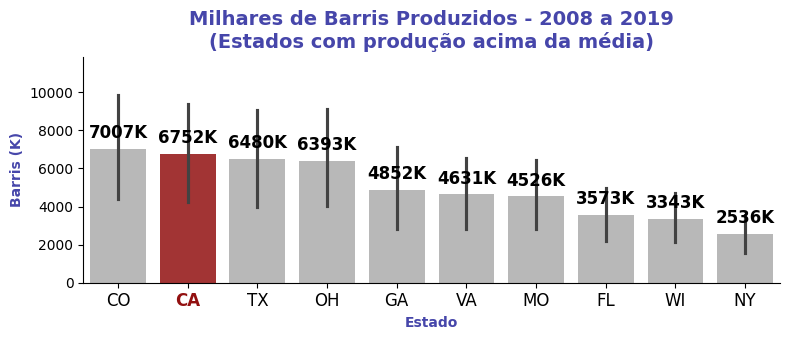

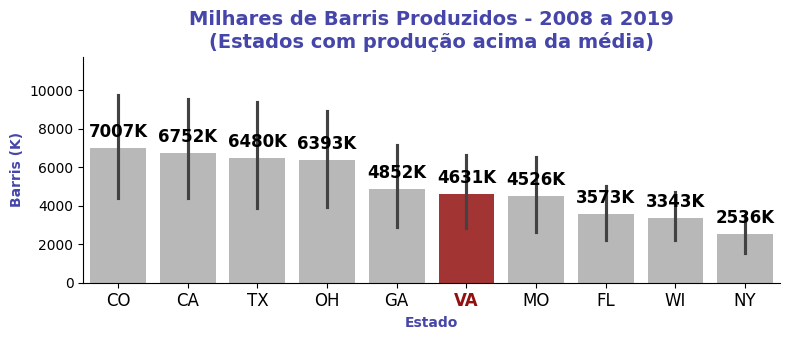

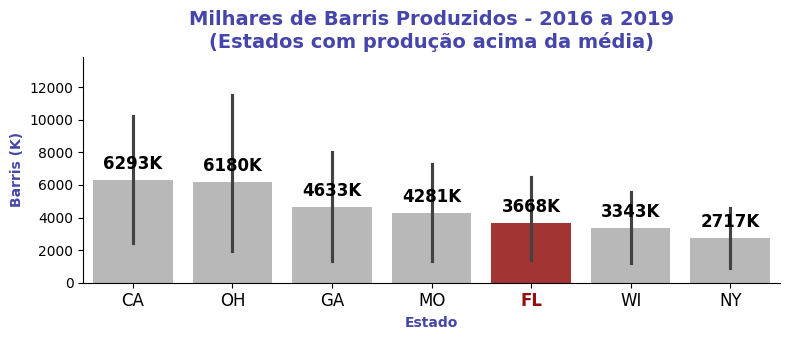

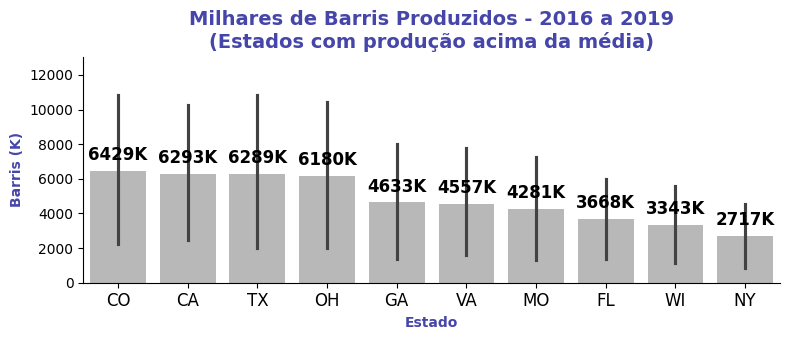

In [113]:
fig, ax = plt.subplots(figsize=(8,3.5))
analisa_producao(df, 'CA', ax)
plt.show()

fig, ax = plt.subplots(figsize=(8,3.5))
analisa_producao(df, 'VA', ax)
plt.show()

fig, ax = plt.subplots(figsize=(8,3.5))
analisa_producao(df[ (df.year > 2015) & (~df.state.isin(['VA','CO','TX'])) ], 'FL', ax)
plt.show()

fig, ax = plt.subplots(figsize=(8,3.5))
analisa_producao(df[ df.year > 2015 ], 'XX', ax)
plt.show()


### Salve sua imagem

Salve e poste a sua imagem com o seu RA (Files com RA de cada aluno!).

In [114]:
#@markdown Arquivos por aluno
from IPython.display import display, HTML
ativ = 'Beer1_'
if RA2 != '':
  content = f'{Aluno1}, salvar e postar a imagem <b>{ativ}{suffix_file_1}_A.png</b>'
  content = f'<span style="font-size: 18px; color: blue;">{content}</span>'
  # display(HTML('<span style="font-family: Georgia; font-size: 24px; color: blue;">Respostas</span>'))
  display(HTML(content))
  print()
  content = f'{Aluno2}, salvar e postar a imagem <b>{ativ}{suffix_file_2}_B.png</b>'
  content = f'<span style="font-size: 18px; color: blue;">{content}</span>'
  display(HTML(content))
else:
  content = f'{Aluno1}, salvar e postar a imagem <b>{ativ}{suffix_file_1}.png</b>'
  content = f'<span style="font-size: 18px; color: blue;">{content}</span>'
  # display(HTML('<span style="font-family: Georgia; font-size: 24px; color: blue;">Respostas</span>'))
  display(HTML(content))
  print()

### Salve seu notebook

Salve e poste seu notebook com o seu RA (Files com RA de cada aluno!).

In [116]:
#@markdown Arquivos por aluno
from IPython.display import display, HTML
ativ = 'Coffe1_'
if RA2 != '':
  content = f'{Aluno1}, salvar e postar notebook <b>IMT_ex_avaliativo_3_{suffix_file_1}_A.ipynb</b>'
  content = f'<span style="font-size: 18px; color: blue;">{content}</span>'
  # display(HTML('<span style="font-family: Georgia; font-size: 24px; color: blue;">Respostas</span>'))
  display(HTML(content))
  print()
  content = f'{Aluno2}, salvar e postar notebook <b>IMT_ex_avaliativo_3_{suffix_file_1}_B.ipynb</b>'
  content = f'<span style="font-size: 18px; color: blue;">{content}</span>'
  display(HTML(content))
else:
  content = f'{Aluno1}, salvar e postar notebook <b>IMT_ex_avaliativo_3_{suffix_file_1}.ipynb</b>'
  content = f'<span style="font-size: 18px; color: blue;">{content}</span>'
  # display(HTML('<span style="font-family: Georgia; font-size: 24px; color: blue;">Respostas</span>'))
  display(HTML(content))
  print()
